### (c) Forecasting the Quarterly Umbrella Sales ($T = 20$, $S = 4$)

This section evaluates forecasting methods for a quarterly seasonal time series of umbrella sales with sample size
$T = 20$ and seasonal period $S = 4$ (five years of quarterly data). Forecast precision is measured using the last
12 observations, i.e. $t = 9,\dots,20$. 

### Methods considered

At least the following methods are considered:

1. **Seasonal Random Walk (SRW)**  
   One-step-ahead forecast:
   $$\hat{Y}_t = Y_{t-S}.$$

2. **Seasonal Random Walk plus Drift (SRW + drift)**  
   One-step-ahead forecast:
   $$\hat{Y}_t = Y_{t-S} + c_{t-1},$$
   where the drift is estimated with an expanding window as the mean seasonal difference:
   $$c_{t-1} = \frac{1}{t-S}\sum_{i=1}^{t-S}\left(Y_{S+i} - Y_i\right).$$

3. **Running Seasonal Regression (expanding-window OLS)**  
   Model with linear trend and seasonal dummies:
   $$Y_t = \mu + \beta t + \sum_{j=1}^{S}\gamma_j D_{j,t} + \varepsilon_t,$$
   with the identification constraint:
   $$\sum_{j=1}^{S}\gamma_j = 0.$$
   One-step-ahead forecasts are computed by re-estimating the regression using data up to time $t-1$ and forecasting
   $Y_t$.

4. **Seasonal Holt–Winters (Additive)**  
   State updates (level $L_t$, trend $G_t$, season $H_t$) and forecast:
   $$\hat{Y}_t = (L_{t-1} + G_{t-1}) + H_{t-S},$$
   $$L_t = \alpha (Y_t - H_{t-S}) + (1-\alpha)(L_{t-1}+G_{t-1}),$$
   $$G_t = \beta (L_t - L_{t-1}) + (1-\beta)G_{t-1},$$
   $$H_t = \gamma (Y_t - L_t) + (1-\gamma)H_{t-S}.$$

5. **Seasonal Holt–Winters (Multiplicative)**  
   Forecast:
   $$\hat{Y}_t = (L_{t-1} + G_{t-1})\,H_{t-S},$$
   Updates:
   $$L_t = \alpha \left(\frac{Y_t}{H_{t-S}}\right) + (1-\alpha)(L_{t-1}+G_{t-1}),$$
   $$G_t = \beta (L_t - L_{t-1}) + (1-\beta)G_{t-1},$$
   $$H_t = \gamma \left(\frac{Y_t}{L_t}\right) + (1-\gamma)H_{t-S}.$$

### Parameter optimization and loss function

The smoothing parameters $\alpha,\beta,\gamma \in (0,1)$ are estimated by minimizing the
**sum of squared one-step-ahead forecast errors (SSE)** over all available in-sample
forecasts after initialization:
$$
\text{SSE}(\alpha,\beta,\gamma)
= \sum_{t=S+1}^{T}
\left( Y_t - \hat{Y}_t(\alpha,\beta,\gamma) \right)^2.
$$

SSE is chosen for the following reasons:

- It corresponds to maximum likelihood estimation under the assumption of Gaussian
  forecast innovations, which is the standard probabilistic interpretation of
  Holt–Winters models.
- Squared loss penalizes large forecast errors strongly, which is important for
  correctly identifying seasonal phase and amplitude.


### Forecast precision metrics (last 12 observations)

Forecast precision is computed over the last 12 observations $t = 9,\dots,20$ using:

$$\text{ME} = \frac{1}{n}\sum_{t=9}^{20} (Y_t - \hat{Y}_t), \qquad
\text{MAE} = \frac{1}{n}\sum_{t=9}^{20} |Y_t - \hat{Y}_t|,$$

$$\text{MAPE} = \frac{100}{n}\sum_{t=9}^{20} \left|\frac{Y_t - \hat{Y}_t}{Y_t}\right|, \qquad
\text{MSE} = \frac{1}{n}\sum_{t=9}^{20} (Y_t - \hat{Y}_t)^2,$$

where $n = 12$. A table reports these metrics for each method, and plots compare one-step-ahead fitted forecasts to
realized values, with a vertical line marking the start of the evaluation window at $t = 9$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ---- import helper functions ----
from helper import (
    seasonal_random_walk_forecast,
    seasonal_random_walk_with_drift_forecast,
    running_seasonal_regression_forecast,
    holt_winters_additive_forecast,
    holt_winters_multiplicative_forecast,
    metrics_row,
    estimate_alpha_beta_gamma_seasonal_hw
)

In [2]:
# ============================================================
# Load data
# ============================================================
df = pd.read_excel("Umbrella.xlsx")
# Take numeric columns and then pick column index 1.
y = df.select_dtypes(include="number").iloc[:, 1].to_numpy(dtype=float)
T = len(y)
S = 4

# Evaluation window: last 12 observations => t = 9..20 (1-based)
# 0-based index start = 8
eval_start = T - 12  # = 8 when T=20eval_start = T - 12  # = 8 when T=20

# Training window for parameter tuning: first 8 observations (t = 1..8)
# train_end = S * 2  # 8 for quarterly, required by HW initialization
# y_train = y[:train_end]

In [3]:
df

,Unnamed: 0,SeasIdx,Umbrella Sales
0,1(1),1,125
1,1(2),2,153
2,1(3),3,106
3,1(4),4,88
4,2(1),1,118
5,2(2),2,161
6,2(3),3,133
7,2(4),4,102
8,3(1),1,138
9,3(2),2,144


In [4]:
# ============================================================
# 1) Seasonal Random Walk (one-step-ahead)
# ============================================================
yhat_srw = seasonal_random_walk_forecast(y, S)

# ============================================================
# 2) Seasonal Random Walk + Drift (one-step-ahead, expanding)
# ============================================================
yhat_srw_drift, c_hat = seasonal_random_walk_with_drift_forecast(y, S)

# ============================================================
# 3) Running Seasonal Regression (one-step-ahead, expanding)
# ============================================================
yhat_reg, mu_hat, b_hat, g_hat = running_seasonal_regression_forecast(y, S)


# ============================================================
# 4) Holt–Winters Additive (expanding-window, re-estimated each step)
#    For each time t:
#      - use history y[:t] to grid-search (alpha, beta, gamma) that minimizes SSE
#      - produce a one-step-ahead forecast for Y_t (using data up to t-1 only)
#    Outputs:
#      aA[t], bA[t], gA[t]  -> chosen parameters at time t (NaN when undefined)
#      yhat_hw_add[t]       -> one-step-ahead forecast for Y_t
#      u_add[t]             -> forecast error: Y_t - yhat_hw_add[t]
#      loss_add[t]          -> best (minimized) in-sample SSE at time t
# ============================================================
aA, bA, gA, yhat_hw_add, u_add, loss_add = estimate_alpha_beta_gamma_seasonal_hw(
    y,
    S,
    multiplicative=False,   # additive seasonality
    criterion="SSE",        # optimize parameters by minimizing SSE
    grid_n=31,              # grid resolution for alpha/beta/gamma
    eps=1e-2                # restrict grid to (eps, 1-eps)
)

# ============================================================
# 5) Holt–Winters Multiplicative (expanding-window, re-estimated each step)
#    Same procedure as (4), but seasonality is multiplicative:
#      Ŷ_t = (level + trend) * seasonal_factor
#    Outputs are analogous:
#      aM[t], bM[t], gM[t], yhat_hw_mul[t], u_mul[t], loss_mul[t]
# ============================================================
aM, bM, gM, yhat_hw_mul, u_mul, loss_mul = estimate_alpha_beta_gamma_seasonal_hw(
    y,
    S,
    multiplicative=True,    # multiplicative seasonality
    criterion="SSE",
    grid_n=31,
    eps=1e-2
)

# ============================================================
# Metrics table on last 12 observations (t = 9..20)
# ============================================================
methods = {
    "Seasonal RW": yhat_srw,
    "Seasonal RW + Drift": yhat_srw_drift,
    "Running Seasonal Regression": yhat_reg,
    "HW Additive (expanding)": yhat_hw_add,
    "HW Multiplicative (expanding)": yhat_hw_mul,
}

rows = []
for name, yhat in methods.items():
    m = metrics_row(y, yhat, start_idx=eval_start)
    rows.append({"Method": name, **m})

In [5]:
metrics_df = pd.DataFrame(rows).sort_values("MSE", ascending=True)
print("\n=== Forecast precision on last 12 observations (t=9..20) ===")
print(metrics_df.to_string(index=False))


=== Forecast precision on last 12 observations (t=9..20) ===
                       Method        ME       MAE      MAPE        MSE
  Running Seasonal Regression -2.266134 13.564774 11.529509 248.451578
      HW Additive (expanding) -5.558731 13.702927 12.289430 276.235857
HW Multiplicative (expanding) -6.104722 13.494256 11.636338 291.758683
                  Seasonal RW  0.416667 18.416667 15.702240 404.250000
          Seasonal RW + Drift -2.684776 19.653385 16.996062 483.471448


This figure compares the realized umbrella sales with one-step-ahead forecasts from all methods.
The vertical line indicates the start of the evaluation window ($t=9$).

### Forecast Precision on the Last 12 Observations ($t = 9,\dots,20$)

The table below reports out-of-sample one-step-ahead forecast accuracy for all considered methods, evaluated on the final 12 observations. Forecasts are generated recursively, and model parameters are estimated using expanding windows where applicable.

| Method | ME | MAE | MAPE | MSE |
|------|----:|----:|-----:|----:|
| Running Seasonal Regression | -2.27 | **13.56** | **11.53** | **248.45** |
| Holt–Winters (Additive, expanding) | -5.56 | 13.70 | 12.29 | 276.24 |
| Holt–Winters (Multiplicative, expanding) | -6.10 | **13.49** | 11.64 | 291.76 |
| Seasonal Random Walk | 0.42 | 18.42 | 15.70 | 404.25 |
| Seasonal Random Walk + Drift | -2.68 | 19.65 | 16.99 | 483.47 |


#### Interpretation

- **Running Seasonal Regression** delivers the strongest overall performance, achieving the lowest **MAPE** and **MSE**, indicating superior accuracy in both relative and squared-error terms.
- **Holt–Winters (Multiplicative)** attains the lowest **MAE**, but at the cost of higher MSE, suggesting occasional large errors.
- Both **Holt–Winters** specifications exhibit negative mean errors, indicating a tendency to under-forecast.
- The **Seasonal Random Walk** and its drift variant perform substantially worse across all metrics, confirming that simple seasonal benchmarks are insufficient for this series. Introducing a drift term further degrades performance


#### Conclusion

For the quarterly series under study, **Running Seasonal Regression provides the most accurate forecasts overall**, particularly in terms of MSE and MAPE. While Holt–Winters models perform competitively in MAE, their systematic under-forecasting and higher variance make them less reliable in this short-sample setting.


### Umbrella Sales: Actual vs One-Step-Ahead Forecasts Figure

The figure compares the observed quarterly umbrella sales with one-step-ahead forecasts from several seasonal forecasting methods.

- The **Actual** series (solid line with markers) exhibits strong and regular seasonality, with recurring peaks and troughs across quarters.
- The **Seasonal Random Walk** and **Seasonal Random Walk with Drift** capture the general seasonal pattern but tend to smooth extreme peaks and troughs, leading to larger deviations from the actual series.
- **Running Seasonal Regression** closely tracks the observed values, particularly around seasonal peaks and turning points.
- **Holt–Winters (Additive, expanding)** provides stable forecasts with moderate seasonal amplitude.
- **Holt–Winters (Multiplicative, expanding)** shows larger seasonal swings and better matches high-demand periods.

The vertical dashed line marks the start of the evaluation window. Overall, models that explicitly account for seasonality and trend follow the data more closely than simple seasonal benchmarks.


In [11]:
colors = {
    "Actual": "tab:blue",
    "Seasonal RW": "tab:orange",
    "Seasonal RW + Drift": "tab:green",
    "Running Seasonal Regression": "tab:red",
    "HW Additive (expanding)": "tab:purple",
    "HW Multiplicative (expanding)": "tab:brown",
}


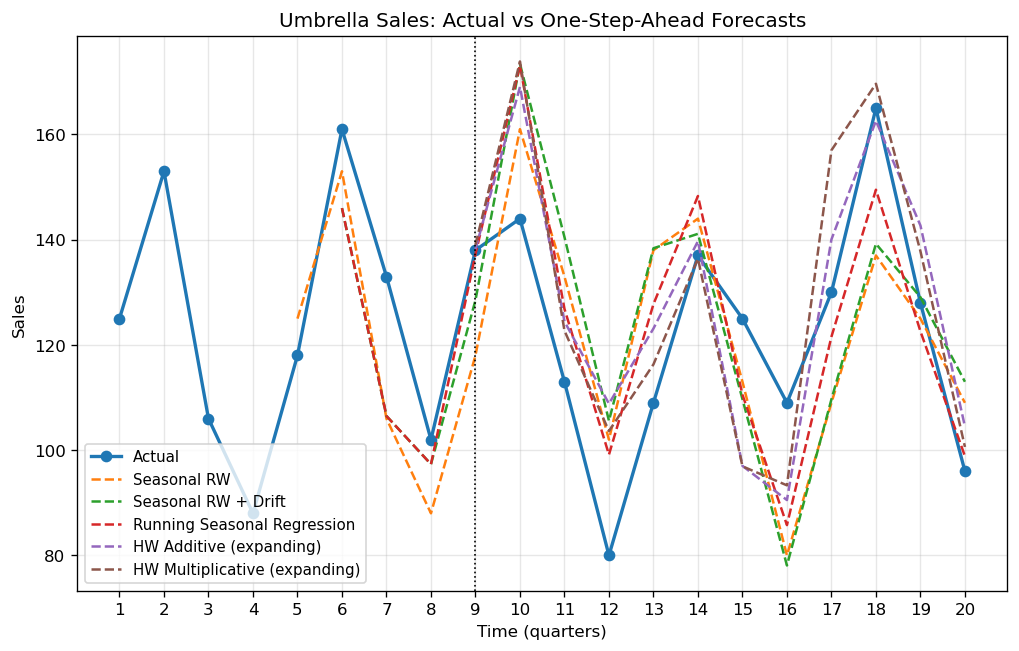

In [12]:
t = np.arange(1, T + 1)
plt.figure(figsize=(10, 6), dpi=120)

# actual data
plt.plot(
    t, y,
    marker="o",
    linewidth=2,
    label="Actual",
    color=colors["Actual"],
)

# forecasts
plt.plot(t, yhat_srw, linestyle="--", label="Seasonal RW",
         color=colors["Seasonal RW"])
plt.plot(t, yhat_srw_drift, linestyle="--", label="Seasonal RW + Drift",
         color=colors["Seasonal RW + Drift"])
plt.plot(t, yhat_reg, linestyle="--", label="Running Seasonal Regression",
         color=colors["Running Seasonal Regression"])
plt.plot(t, yhat_hw_add, linestyle="--", label="HW Additive (expanding)",
         color=colors["HW Additive (expanding)"])
plt.plot(t, yhat_hw_mul, linestyle="--", label="HW Multiplicative (expanding)",
         color=colors["HW Multiplicative (expanding)"])

plt.axvline(eval_start + 1, color="black", linestyle=":", linewidth=1)

plt.title("Umbrella Sales: Actual vs One-Step-Ahead Forecasts")
plt.xlabel("Time (quarters)")
plt.ylabel("Sales")
plt.xticks(t)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()


### One-Step-Ahead Forecast Errors (Last 12 Observations)

This figure shows the one-step-ahead forecast errors for each method over the final 12 quarters, with the horizontal line at zero indicating unbiased forecasts.

- **Seasonal Random Walk** and **Seasonal Random Walk with Drift** exhibit large and volatile errors, particularly around seasonal turning points, indicating limited ability to adapt to changing levels.
- **Running Seasonal Regression** produces smaller and more stable errors, remaining closer to zero across most periods.
- **Holt–Winters (Additive, expanding)** shows systematic under-forecasting in several quarters, reflected by persistently negative errors.
- **Holt–Winters (Multiplicative, expanding)** displays the largest variability, with sharp positive and negative spikes, especially during high-demand periods.

Overall, models that explicitly capture seasonal structure and allow for adaptive parameters yield more stable and accurate one-step-ahead forecasts, as evidenced by lower error magnitudes and reduced volatility.


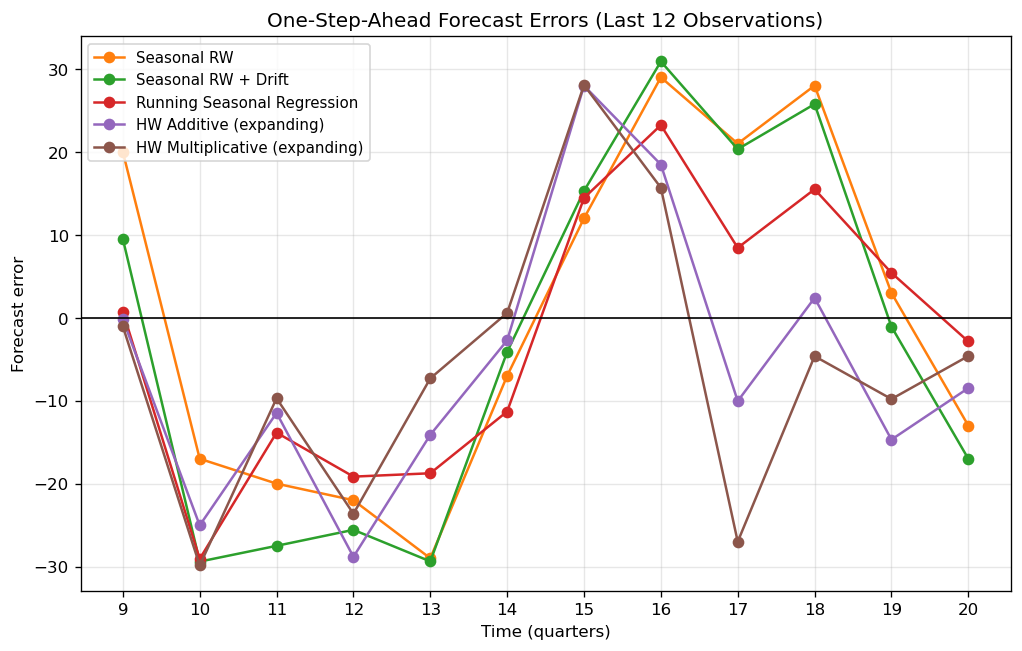

In [13]:
t_eval = t[eval_start:]
t2 = np.arange(eval_start + 1, T + 1)

plt.figure(figsize=(10, 6), dpi=120)

plt.plot(t_eval, y[eval_start:] - yhat_srw[eval_start:], marker="o",
         label="Seasonal RW", color=colors["Seasonal RW"])
plt.plot(t_eval, y[eval_start:] - yhat_srw_drift[eval_start:], marker="o",
         label="Seasonal RW + Drift", color=colors["Seasonal RW + Drift"])
plt.plot(t_eval, y[eval_start:] - yhat_reg[eval_start:], marker="o",
         label="Running Seasonal Regression", color=colors["Running Seasonal Regression"])
plt.plot(t_eval, y[eval_start:] - yhat_hw_add[eval_start:], marker="o",
         label="HW Additive (expanding)", color=colors["HW Additive (expanding)"])
plt.plot(t_eval, y[eval_start:] - yhat_hw_mul[eval_start:], marker="o",
         label="HW Multiplicative (expanding)", color=colors["HW Multiplicative (expanding)"])

plt.axhline(0, color="black", linewidth=1)
plt.title("One-Step-Ahead Forecast Errors (Last 12 Observations)")
plt.xlabel("Time (quarters)")
plt.ylabel("Forecast error")
plt.xticks(t2)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()
